# Load Libraries

## Importing libraries

In [ ]:
# dl packages
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.preprocessing.text import one_hot
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

# ml packages
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import pickle
import nltk
import re
from nltk.stem import PorterStemmer

import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud


# Load data

In [3]:
train_data = pd.read_csv("train.txt", header=None, sep=";", names=["Comment", "Emotion"], encoding="utf-8")
# get all words length in comment
train_data['length'] = [len(x) for x in train_data['Comment']]

In [4]:
train_data

,Comment,Emotion,length
0,i didnt feel humiliated,sadness,23
1,i can go from feeling so hopeless to so damned...,sadness,108
2,im grabbing a minute to post i feel greedy wrong,anger,48
3,i am ever feeling nostalgic about the fireplac...,love,92
4,i am feeling grouchy,anger,20
...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101
15996,i am now turning and i feel pathetic that i am...,sadness,102
15997,i feel strong and good overall,joy,30
15998,i feel like this was such a rude comment and i...,anger,59


In [5]:
train_data.shape

(16000, 3)

In [6]:
train_data.isnull().sum()

Comment    0
Emotion    0
length     0
dtype: int64

In [7]:
train_data.duplicated().sum()

1

# EDA

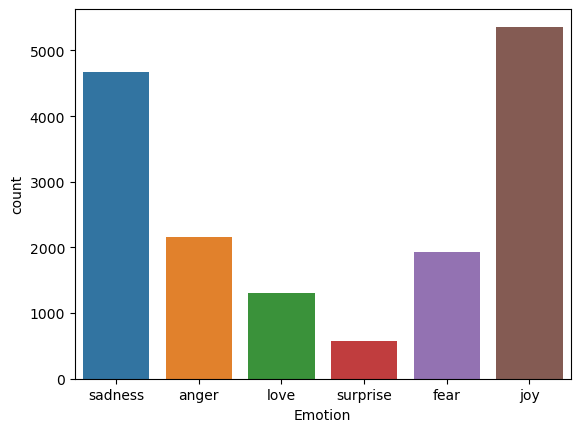

In [8]:
sns.countplot(x = train_data['Emotion'])
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


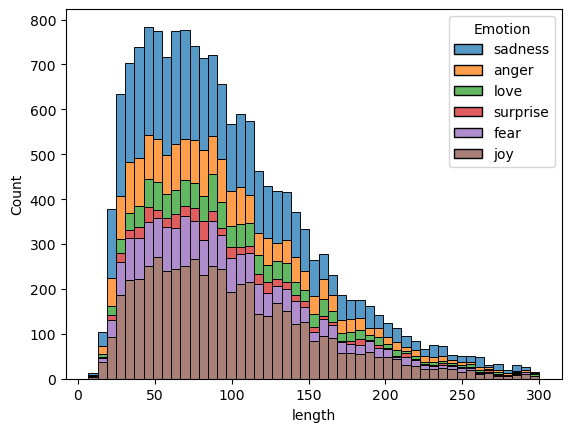

In [9]:
# data distribution
df2 = train_data.copy()
df2['length'] = [len(x) for x in df2['Comment']]

# Convert the 'length' column to a numpy array
length_values = df2['length'].values

# Use sns.histplot instead of sns.kdeplot for simplicity
sns.histplot(data=df2, x='length', hue='Emotion', multiple='stack')

plt.show()

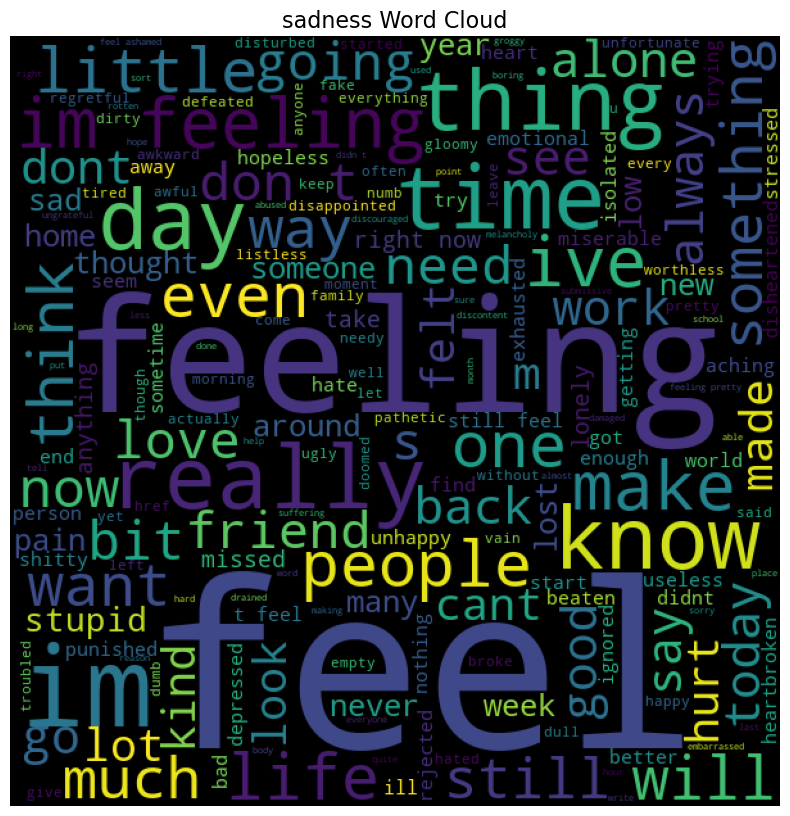

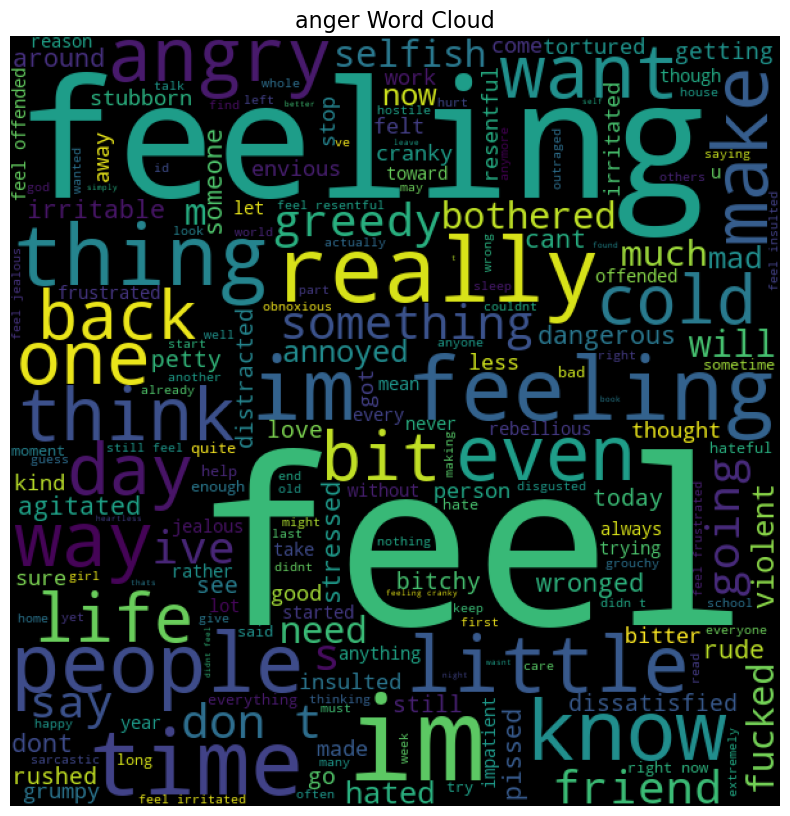

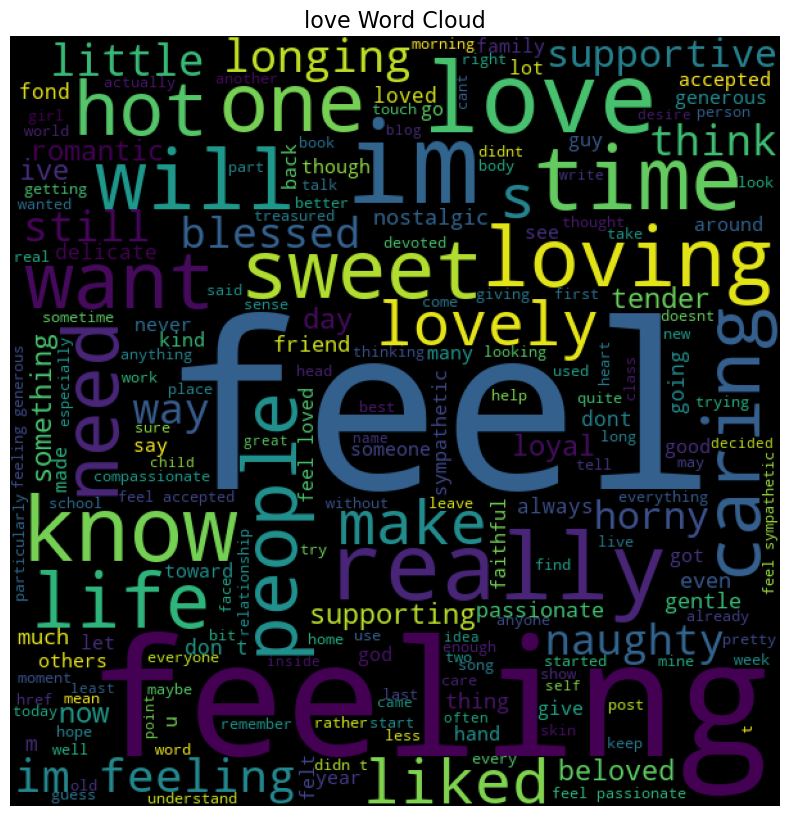

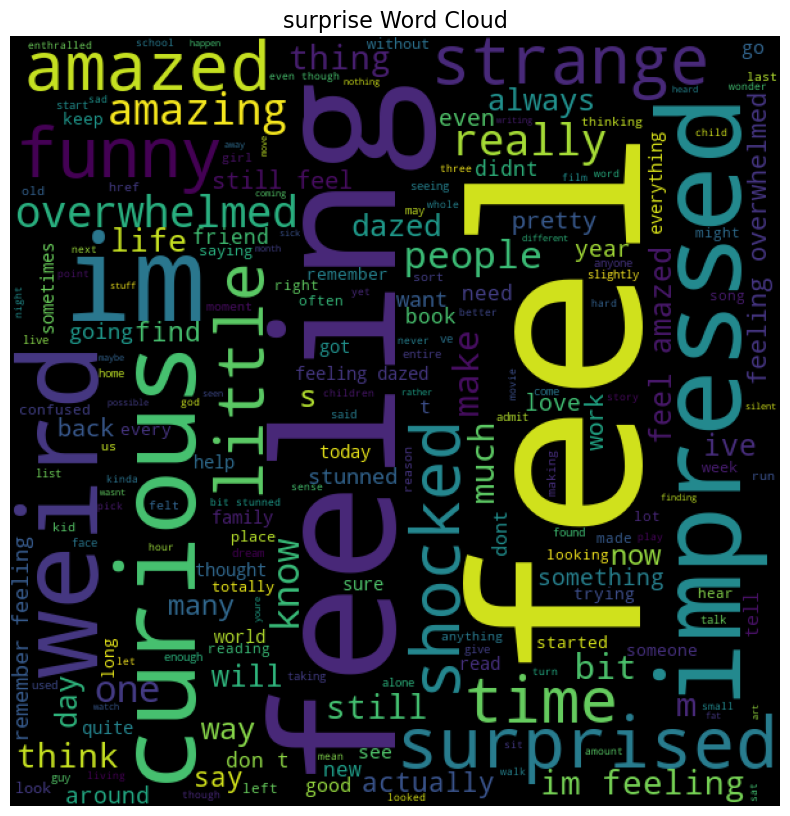

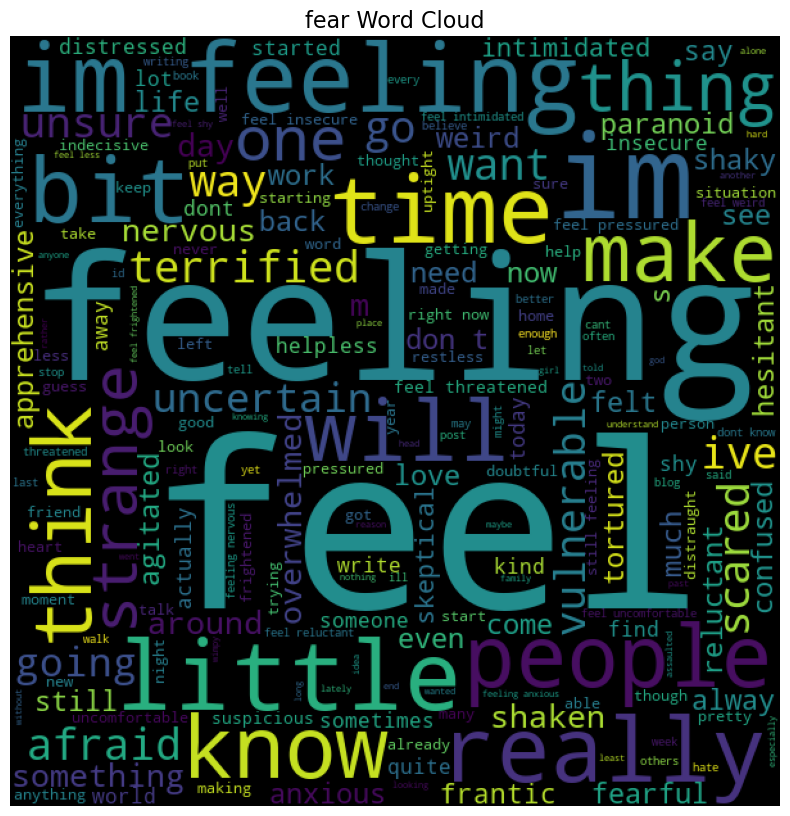

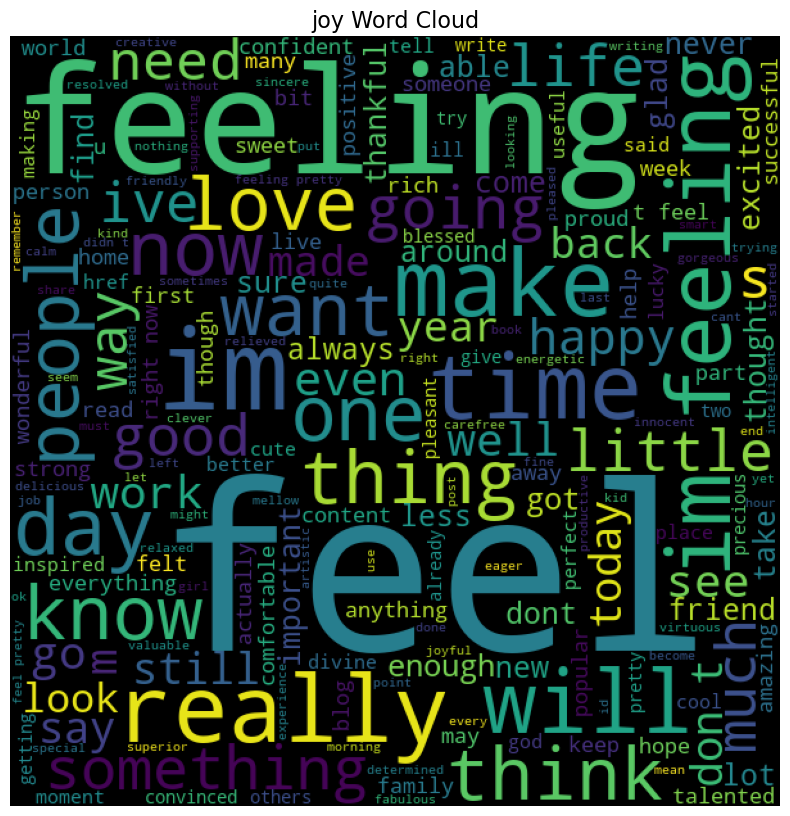

In [10]:
# Words cloud for each emotions
def words_cloud(wordcloud, df):
    plt.figure(figsize=(10, 10))
    plt.title(df+' Word Cloud', size = 16)
    plt.imshow(wordcloud) 
    # No axis details
    plt.axis("off");
emotions_list = train_data['Emotion'].unique()
for emotion in emotions_list:
    text = ' '.join([sentence for sentence in train_data.loc[train_data['Emotion'] == emotion,'Comment']])
    wordcloud = WordCloud(width = 600, height = 600).generate(text)
    words_cloud(wordcloud, emotion)

# Data Preprocessing
# Encode emotions

In [11]:
lb = LabelEncoder()
train_data['Emotion'] = lb.fit_transform(train_data['Emotion'])

In [12]:
train_data

,Comment,Emotion,length
0,i didnt feel humiliated,4,23
1,i can go from feeling so hopeless to so damned...,4,108
2,im grabbing a minute to post i feel greedy wrong,0,48
3,i am ever feeling nostalgic about the fireplac...,3,92
4,i am feeling grouchy,0,20
...,...,...,...
15995,i just had a very brief time in the beanbag an...,4,101
15996,i am now turning and i feel pathetic that i am...,4,102
15997,i feel strong and good overall,2,30
15998,i feel like this was such a rude comment and i...,0,59


# Applying Machine Learning

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [14]:
df = train_data.copy() # copy df from train_data because we will use this for deep learing next

In [15]:
df

,Comment,Emotion,length
0,i didnt feel humiliated,4,23
1,i can go from feeling so hopeless to so damned...,4,108
2,im grabbing a minute to post i feel greedy wrong,0,48
3,i am ever feeling nostalgic about the fireplac...,3,92
4,i am feeling grouchy,0,20
...,...,...,...
15995,i just had a very brief time in the beanbag an...,4,101
15996,i am now turning and i feel pathetic that i am...,4,102
15997,i feel strong and good overall,2,30
15998,i feel like this was such a rude comment and i...,0,59


In [16]:
# Data cleaning and preprocessing
# Download NLTK stopwords
nltk.download('stopwords')
stopwords = set(nltk.corpus.stopwords.words('english'))
def clean_text(text):
    stemmer = PorterStemmer()
    text = re.sub("[^a-zA-Z]", " ", text)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stopwords]
    return " ".join(text)

df['cleaned_comment'] = df['Comment'].apply(clean_text)

[nltk_data] Downloading package stopwords to C:\Users\Jawad
[nltk_data]     Sheikh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_comment'],df['Emotion'],test_size=0.2,random_state=42)

In [18]:
# Vectorization using TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [19]:
# Multi-class classification using different algorithms
classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
}

for name, clf in classifiers.items():
    print(f"\n===== {name} =====")
    clf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = clf.predict(X_test_tfidf)
    accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
    print(f"\nAccuracy using TF-IDF: {accuracy_tfidf}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_tfidf))


===== Multinomial Naive Bayes =====

Accuracy using TF-IDF: 0.655
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.31      0.46       427
           1       0.91      0.24      0.38       397
           2       0.58      0.98      0.73      1021
           3       1.00      0.03      0.06       296
           4       0.70      0.91      0.79       946
           5       1.00      0.01      0.02       113

    accuracy                           0.66      3200
   macro avg       0.85      0.41      0.41      3200
weighted avg       0.76      0.66      0.58      3200


===== Logistic Regression =====

Accuracy using TF-IDF: 0.829375
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       427
           1       0.84      0.73      0.78       397
           2       0.78      0.94      0.85      1021
           3       0.80      0.49      0.61       296
       

In [20]:
# selecting model
lg = LogisticRegression()
lg.fit(X_train_tfidf, y_train)
lg_y_pred = lg.predict(X_test_tfidf)

In [21]:
def predict_emotion(input_text):
    cleaned_text = clean_text(input_text)
    input_vectorized = tfidf_vectorizer.transform([cleaned_text])

    # Predict emotion
    predicted_label = lg.predict(input_vectorized)[0]
    predicted_emotion = lb.inverse_transform([predicted_label])[0]
    label =  np.max(lg.predict(input_vectorized))

    return predicted_emotion,label

# Example usage 
sentences = [
            "i didnt feel humiliated",
            "i feel strong and good overall",
            "im grabbing a minute to post i feel greedy wrong",
            "He was speechles when he found out he was accepted to this new job",
            "This is outrageous, how can you talk like that?",
            "I feel like im all alone in this world",
            "He is really sweet and caring",
            "You made me very crazy",
            "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
            "i am feeling grouchy",
            "He hates you"
            ]
for sentence in sentences:
    print(sentence)
    pred_emotion, label = predict_emotion(sentence)
    print("Prediction :",pred_emotion)
    print("Label :",label)
    print("================================================================")

i didnt feel humiliated
Prediction : sadness
Label : 4
i feel strong and good overall
Prediction : joy
Label : 2
im grabbing a minute to post i feel greedy wrong
Prediction : anger
Label : 0
He was speechles when he found out he was accepted to this new job
Prediction : joy
Label : 2
This is outrageous, how can you talk like that?
Prediction : anger
Label : 0
I feel like im all alone in this world
Prediction : sadness
Label : 4
He is really sweet and caring
Prediction : love
Label : 3
You made me very crazy
Prediction : sadness
Label : 4
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Prediction : love
Label : 3
i am feeling grouchy
Prediction : anger
Label : 0
He hates you
Prediction : anger
Label : 0


In [22]:
# save files
import pickle
pickle.dump(lg,open("logistic_regresion.pkl",'wb'))
pickle.dump(lb,open("label_encoder.pkl",'wb'))
pickle.dump(tfidf_vectorizer,open("tfidf_vectorizer.pkl",'wb'))

In [23]:
import sklearn
print(sklearn.__version__) # use this version in pycharm

1.6.0


# Applying Deep learning Using LSTM

# Text Cleaning, Ecoding, and Padding

In [24]:
# Text cleaning function
def text_cleaning(df, column, vocab_size, max_len):
    stemmer = PorterStemmer()
    corpus = []

    for text in df[column]:
        text = re.sub("[^a-zA-Z]", " ", text)
        text = text.lower()
        text = text.split()
        text = [stemmer.stem(word) for word in text if word not in stopwords]
        text = " ".join(text)
        corpus.append(text)

    one_hot_word = [one_hot(input_text=word, n=vocab_size) for word in corpus]
    pad = pad_sequences(sequences=one_hot_word, maxlen=max_len, padding='pre')
    return pad

# Text cleaning and encoding
x_train = text_cleaning(train_data, "Comment", vocab_size=11000, max_len=300)
y_train = to_categorical(train_data["Emotion"])

# Model Building and Training

In [ ]:
# Build and compile the model
model = Sequential()
model.add(Embedding(input_dim=11000, output_dim=150, input_length=300))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(64, activation='sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
callback = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
model.fit(x_train, y_train, epochs=10, batch_size=64, verbose=1, callbacks=[callback])

# Predictive System

In [26]:
# Text cleaning function
def sentence_cleaning(sentence):
    stemmer = PorterStemmer()
    corpus = []
    text = re.sub("[^a-zA-Z]", " ", sentence)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stopwords]
    text = " ".join(text)
    corpus.append(text)
    one_hot_word = [one_hot(input_text=word, n=11000) for word in corpus]
    pad = pad_sequences(sequences=one_hot_word, maxlen=300, padding='pre')
    return pad

# load model and predict 
sentences = [
            "i feel strong and good overall",
            "im grabbing a minute to post i feel greedy wrong",
            "He was speechles when he found out he was accepted to this new job",
            "This is outrageous, how can you talk like that?",
            "I feel like im all alone in this world",
            "He is really sweet and caring",
            "You made me very crazy",
            "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
            "i am feeling grouchy",
            "He hates you"
            ]
for sentence in sentences:
    print(sentence)
    sentence = sentence_cleaning(sentence)
    result = lb.inverse_transform(np.argmax(model.predict(sentence), axis=-1))[0]
    proba =  np.max(model.predict(sentence))
    print(f"{result} : {proba}\n\n")

i feel strong and good overall
1/1 [==============================] - 0s 54ms/step
joy : 0.9994731545448303


im grabbing a minute to post i feel greedy wrong
1/1 [==============================] - 0s 73ms/step
anger : 0.9987340569496155


He was speechles when he found out he was accepted to this new job
1/1 [==============================] - 0s 58ms/step
love : 0.42459845542907715


This is outrageous, how can you talk like that?
1/1 [==============================] - 0s 55ms/step
anger : 0.9792674779891968


I feel like im all alone in this world
1/1 [==============================] - 0s 55ms/step
sadness : 0.9895405173301697


He is really sweet and caring
1/1 [==============================] - 0s 56ms/step
love : 0.8904396295547485


You made me very crazy
1/1 [==============================] - 0s 54ms/step
anger : 0.4816095232963562


i am ever feeling nostalgic about the fireplace i will know that it is still on the property
1/1 [==============================] - 0s 52ms/step
lo

# Save the model and files

In [ ]:

model.save('model1.h5')

# Save the LabelEncoder
with open('lb1.pkl', 'wb') as f:
    pickle.dump(lb, f)

# Save vocabulary size and max length
vocab_info = {'vocab_size': 11000, 'max_len': 300}
with open('vocab_info.pkl', 'wb') as f:
    pickle.dump(vocab_info, f)

In [9]:
# use this version
import tensorflow
import keras
print(keras.__version__)
print(tensorflow.__version__)

2.15.0
2.15.0


In [28]:
# Train the model and store training history
callback = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
history = model.fit(
    x_train, 
    y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.2,
    verbose=1, 
    callbacks=[callback]
)

# Extract accuracy and loss values
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']




Epoch 1/10
200/200 [==============================] - 58s 288ms/step - loss: 0.0657 - accuracy: 0.9775 - val_loss: 0.0605 - val_accuracy: 0.9784
Epoch 2/10
200/200 [==============================] - 76s 381ms/step - loss: 0.0609 - accuracy: 0.9795 - val_loss: 0.0754 - val_accuracy: 0.9728
Epoch 3/10
200/200 [==============================] - 83s 412ms/step - loss: 0.0573 - accuracy: 0.9805 - val_loss: 0.0866 - val_accuracy: 0.9681


In [29]:
# Save the training metrics
import pickle
metrics = {
    "train_accuracy": acc_values,
    "val_accuracy": val_acc_values,
    "train_loss": loss_values,
    "val_loss": val_loss_values
}

with open("training_metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

print("✅ Training metrics saved successfully in 'training_metrics.pkl'")



✅ Training metrics saved successfully in 'training_metrics.pkl'


In [ ]:
import pickle
import numpy as np

# Assuming you already have:
# model  → your trained model
# X_test → test data (tokenized/padded)
# y_test → true test labels
# lb     → LabelEncoder or LabelBinarizer used for encoding labels

# --- Generate Predictions ---
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)   # converts probabilities to label indices
y_true = np.argmax(y_test, axis=1)         # if y_test is one-hot encoded

# --- Save for performance_page.py ---
pred_data = {
    "y_true": y_true,
    "y_pred": y_pred,
    "labels": lb.classes_
}
with open("predictions.pkl", "wb") as f:
    pickle.dump(pred_data, f)

print("✅ Predictions saved successfully to predictions.pkl")


In [35]:
print(type(X_test))
print(np.array(X_test).shape)


<class 'pandas.core.series.Series'>
(3200,)


In [36]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert Pandas Series to list of text
X_test_text = X_test.tolist()

# Tokenize using your saved tokenizer
from tensorflow.keras.preprocessing.text import tokenizer_from_json
import json

# Load the same tokenizer used during training
with open("tokenizer.json", "r") as f:
    tokenizer_data = json.load(f)
tokenizer = tokenizer_from_json(tokenizer_data)

# Recreate padded sequences (must match training max_length)
max_length = 100   # ⚠️ replace with the same max_length you used during training

X_test_seq = tokenizer.texts_to_sequences(X_test_text)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Ensure float32 dtype for TensorFlow
X_test_pad = np.array(X_test_pad).astype('float32')

# Predict
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)  # if one-hot encoded


FileNotFoundError: [Errno 2] No such file or directory: 'tokenizer.json'

In [38]:
from tensorflow.keras.preprocessing.text import Tokenizer
import json

# Assuming you used 'Tokenizer' during training
tokenizer = Tokenizer(num_words=11000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_comment'])

# Save tokenizer
tokenizer_json = tokenizer.to_json()
with open("tokenizer.json", "w") as f:
    f.write(tokenizer_json)


In [41]:
import json
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle

# Load saved tokenizer
with open("tokenizer.json", "r") as f:
    tokenizer_data = json.load(f)
tokenizer = tokenizer_from_json(json.dumps(tokenizer_data))

# Convert test text to numeric padded form
max_length = 300  # must match your training setting
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='pre')

# Predict using model
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Handle y_test depending on its format
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    # One-hot encoded
    y_true = np.argmax(y_test, axis=1)
else:
    # Already label encoded
    y_true = y_test.values if hasattr(y_test, "values") else y_test

# Save predictions
pred_data = {"y_true": y_true, "y_pred": y_pred, "labels": lb.classes_}
pickle.dump(pred_data, open("predictions.pkl", "wb"))

print("✅ Predictions saved successfully as predictions.pkl")


100/100 [==============================] - 5s 45ms/step
✅ Predictions saved successfully as predictions.pkl


In [42]:
import pickle

with open("training_metrics.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys() if isinstance(data, dict) else data)


<class 'dict'>
dict_keys(['train_accuracy', 'val_accuracy', 'train_loss', 'val_loss'])
